# Behavioral Portfolio Optimizer Using NIFTY 50 Stocks

## Objective
### To develop a portfolio optimization model that integrates traditional mean-variance optimization with behavioral finance principles to account for investor loss aversion and psychological risk preferences.

### The goal of this project is to:

* Build an optimized portfolio using real stock market data
* Compare traditional optimization vs behavioral optimization
* Reduce downside emotional risk
* Improve long-term stability of returns

*  The traditional model is based on - Modern Portfolio Theory
* The behavioral model is inspired by - Prospect Theory

## Dataset Selection

🔹 Stocks (Portfolio Assets)

* From
NIFTY 50

Example 10 stocks:

* RELIANCE.NS
* TCS.NS
* INFY.NS
* HDFCBANK.NS
* ICICIBANK.NS
* ITC.NS
* LT.NS
* HINDUNILVR.NS
* SBIN.NS
* BHARTIARTL.NS

🔹 Benchmark Index

* ^NSEI (NIFTY 50 Index)

In [294]:
 pip install yfinance 

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: yfinance in c:\users\cw\anaconda3\lib\site-packages (1.2.0)



In [295]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [296]:
data.columns

MultiIndex([( 'Close', 'BHARTIARTL.NS'),
            ( 'Close',   'HDFCBANK.NS'),
            ( 'Close', 'HINDUNILVR.NS'),
            ( 'Close',  'ICICIBANK.NS'),
            ( 'Close',       'INFY.NS'),
            ( 'Close',        'ITC.NS'),
            ( 'Close',         'LT.NS'),
            ( 'Close',   'RELIANCE.NS'),
            ( 'Close',       'SBIN.NS'),
            ( 'Close',        'TCS.NS'),
            (  'High', 'BHARTIARTL.NS'),
            (  'High',   'HDFCBANK.NS'),
            (  'High', 'HINDUNILVR.NS'),
            (  'High',  'ICICIBANK.NS'),
            (  'High',       'INFY.NS'),
            (  'High',        'ITC.NS'),
            (  'High',         'LT.NS'),
            (  'High',   'RELIANCE.NS'),
            (  'High',       'SBIN.NS'),
            (  'High',        'TCS.NS'),
            (   'Low', 'BHARTIARTL.NS'),
            (   'Low',   'HDFCBANK.NS'),
            (   'Low', 'HINDUNILVR.NS'),
            (   'Low',  'ICICIBANK.NS'),
            (   

## Define Stock List

In [298]:

stocks = [
    "RELIANCE.NS", "TCS.NS", "INFY.NS", "HDFCBANK.NS",
    "ICICIBANK.NS", "ITC.NS", "LT.NS",
    "HINDUNILVR.NS", "SBIN.NS", "BHARTIARTL.NS"
]

data = yf.download(
    stocks,
    start="2019-01-01",
    end="2024-12-31",
    auto_adjust=True
)

prices = data["Close"]
prices = prices.dropna()

returns = prices.pct_change().dropna()

[*********************100%***********************]  10 of 10 completed


### “I fetched historical equity and index data programmatically using Yahoo Finance API and built a behavioral portfolio optimization framework on real NSE data.”

## Benchmark Index (Also via yfinance)

In [301]:
nifty = yf.download("^NSEI", start="2019-01-01", end="2024-12-31", auto_adjust=True)

nifty_returns = nifty["Close"].pct_change().dropna()

[*********************100%***********************]  1 of 1 completed


## Basic Dataset Inspection

In [303]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1480 entries, 2019-01-01 to 2024-12-30
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   BHARTIARTL.NS  1480 non-null   float64
 1   HDFCBANK.NS    1480 non-null   float64
 2   HINDUNILVR.NS  1480 non-null   float64
 3   ICICIBANK.NS   1480 non-null   float64
 4   INFY.NS        1480 non-null   float64
 5   ITC.NS         1480 non-null   float64
 6   LT.NS          1480 non-null   float64
 7   RELIANCE.NS    1480 non-null   float64
 8   SBIN.NS        1480 non-null   float64
 9   TCS.NS         1480 non-null   float64
dtypes: float64(10)
memory usage: 127.2 KB


In [304]:
prices.describe()

Ticker,BHARTIARTL.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,LT.NS,RELIANCE.NS,SBIN.NS,TCS.NS
count,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000
mean,725.484872,678.364575,2163.096842,714.956585,1188.236775,255.491879,1918.819544,1016.214583,447.073645,2787.797168
std,352.777291,114.306717,317.651942,279.175805,392.969221,105.312303,899.872118,284.856442,191.068065,745.344113
min,264.012421,363.573364,1480.763794,274.681244,452.361267,107.234116,653.294067,395.482483,139.191833,1422.269409
25%,489.823311,585.372314,1956.777069,454.034088,703.689651,169.411816,1238.157867,827.081314,288.556564,1926.247772
50%,672.887817,703.339569,2197.551025,699.432526,1304.918945,208.300217,1646.552979,1080.744324,441.579346,2927.279053
75%,843.668655,768.683517,2421.531067,917.485352,1468.549103,372.524063,2349.793640,1196.581329,561.219116,3273.929260
max,1756.416504,923.393494,2939.454346,1335.792847,1942.221191,476.588715,3910.826416,1589.138184,887.822937,4311.585449


In [305]:
returns.describe()

Ticker,BHARTIARTL.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,LT.NS,RELIANCE.NS,SBIN.NS,TCS.NS
count,1479.000000,1479.000000,1479.000000,1479.000000,1479.000000,1479.000000,1479.000000,1479.000000,1479.000000,1479.000000
mean,0.001341,0.000510,0.000348,0.001072,0.000972,0.000645,0.000840,0.000767,0.000916,0.000735
std,0.018721,0.016488,0.014606,0.019660,0.017546,0.015808,0.017760,0.018463,0.020987,0.015252
min,-0.119529,-0.126069,-0.088707,-0.178479,-0.161881,-0.120798,-0.162658,-0.131539,-0.144040,-0.094103
25%,-0.008602,-0.007245,-0.007211,-0.008103,-0.008113,-0.006759,-0.008306,-0.008868,-0.009216,-0.006947
50%,0.000254,0.000589,-0.000214,0.000919,0.000909,0.000197,0.000593,0.000455,0.001176,0.000521
75%,0.010126,0.007757,0.007150,0.009874,0.009693,0.008640,0.009433,0.009316,0.011166,0.008545
max,0.112908,0.115996,0.134998,0.137624,0.120334,0.084337,0.094352,0.147180,0.138288,0.098451


## Price Trend Visualization

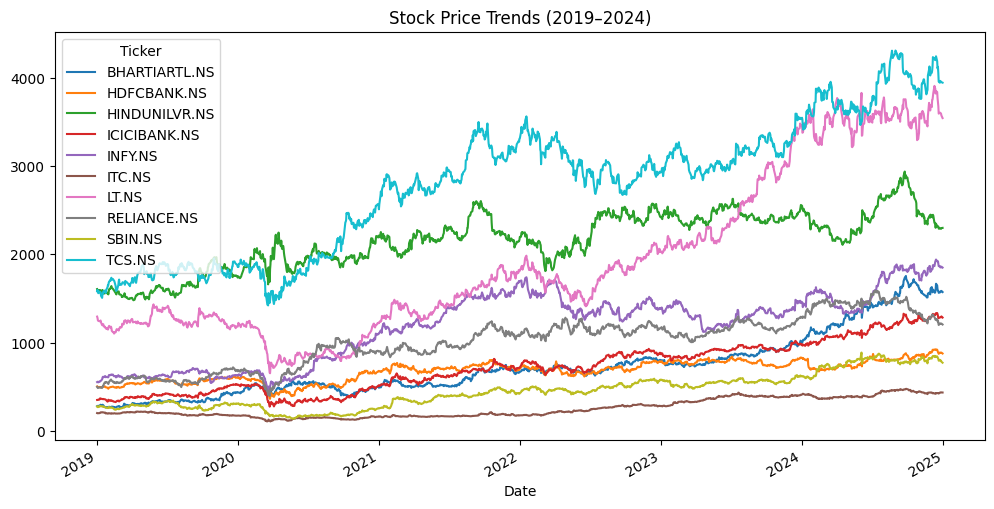

In [307]:
prices.plot(figsize=(12,6))
plt.title("Stock Price Trends (2019–2024)")
plt.savefig("plot1.jpg", dpi=300, bbox_inches='tight')
plt.show()

Strong upward trend (post-2020 recovery)
Most stocks show a significant upward trend after the 2020 dip — indicating strong post-COVID recovery.

✅ March 2020 Crash Visible
There is a sharp dip across almost all stocks around early 2020.
→ This reflects the COVID-19 market crash.

✅ Different Growth Speeds

Some stocks grew aggressively (high slope).

Others remained relatively stable.

Shows sector-wise performance differences.

✅ Volatility Differences

Steeper and more irregular lines = more volatile.

Smoother lines = relatively stable stocks.

## Daily Return Distribution

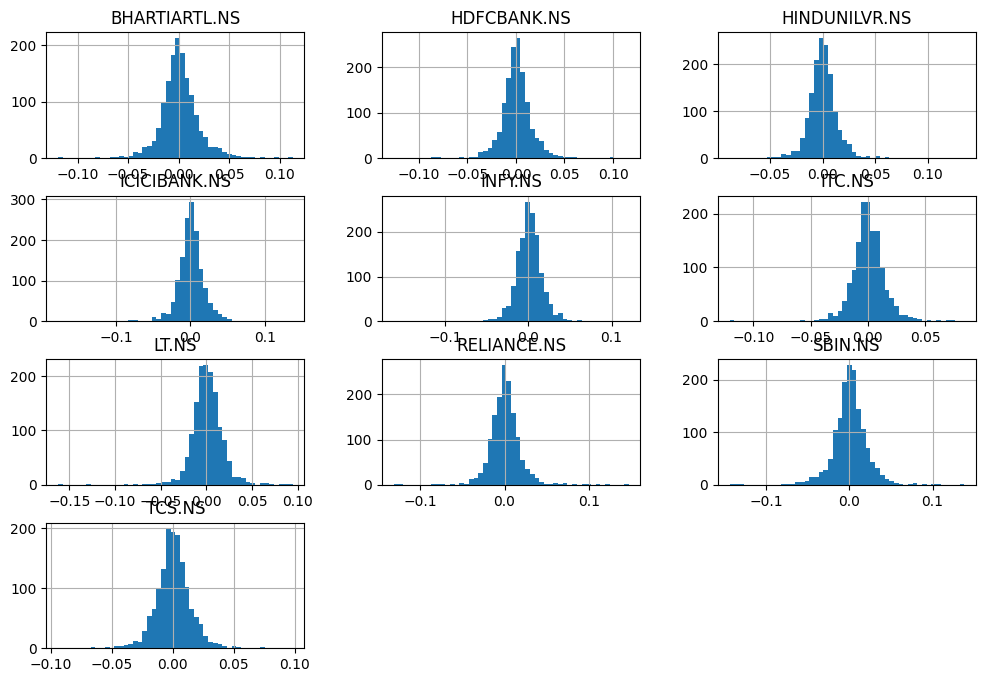

In [310]:
returns.hist(bins=50, figsize=(12,8))
plt.show()

✅ Bell-shaped distributions
Most stocks show approximately normal distribution of returns.

✅ Fat Tails
Some stocks have extreme return spikes (both positive & negative).
→ Indicates higher risk.

✅ Volatility Comparison

Wider histogram → higher volatility

Narrower histogram → more stable returns

## Correlation Matrix

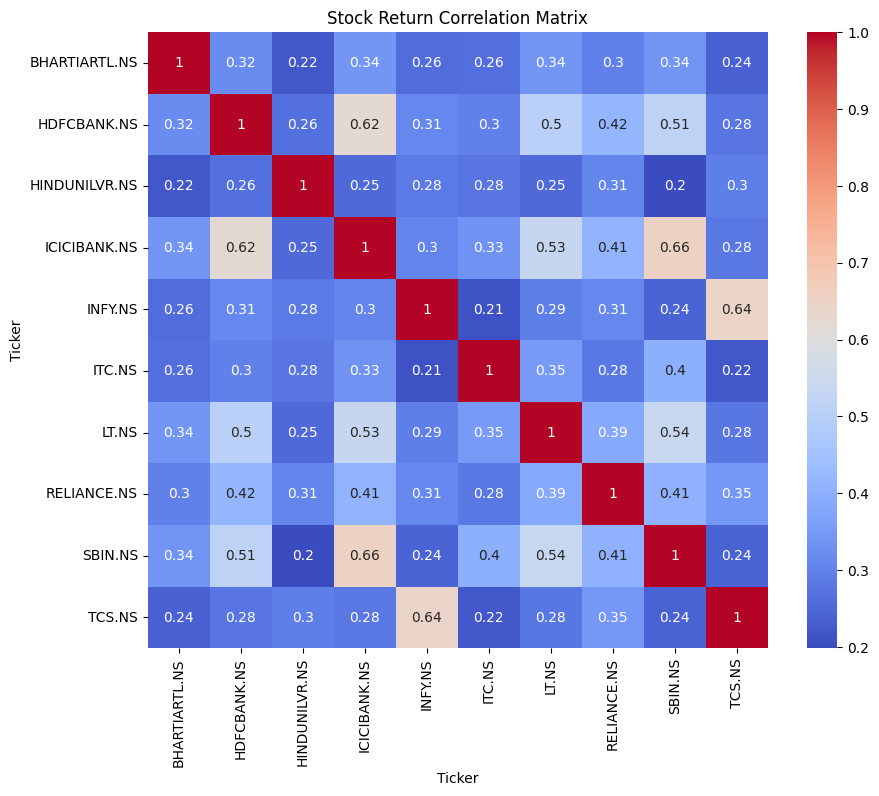

In [313]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(returns.corr(), annot=True, cmap="coolwarm")
plt.title("Stock Return Correlation Matrix")
plt.show()

✅ High Correlation (> 0.7)
Stocks in similar sectors move together.
→ Adding both may not reduce risk significantly.

✅ Moderate Correlation (0.3–0.6)
Some diversification benefit.

✅ Low Correlation (< 0.3)
Best candidates for diversification.

## Volatility Comparison

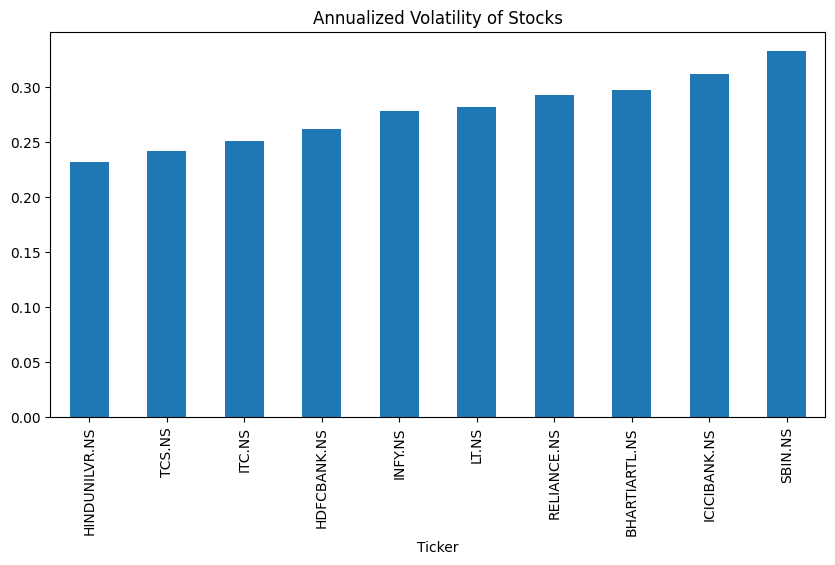

In [316]:
volatility = returns.std() * np.sqrt(252)
volatility.sort_values().plot(kind="bar", figsize=(10,5))
plt.title("Annualized Volatility of Stocks")
plt.savefig("plot2.jpg", dpi=300, bbox_inches='tight')
plt.show()

✅ Some stocks clearly have higher annualized volatility (~30%+)
→ These are aggressive / high-risk stocks.

✅ Some stocks are around 20–22% volatility
→ Comparatively stable.

✅ Risk dispersion exists across stocks
→ Good opportunity for risk balancing in portfolio construction.

## Cumulative Returns

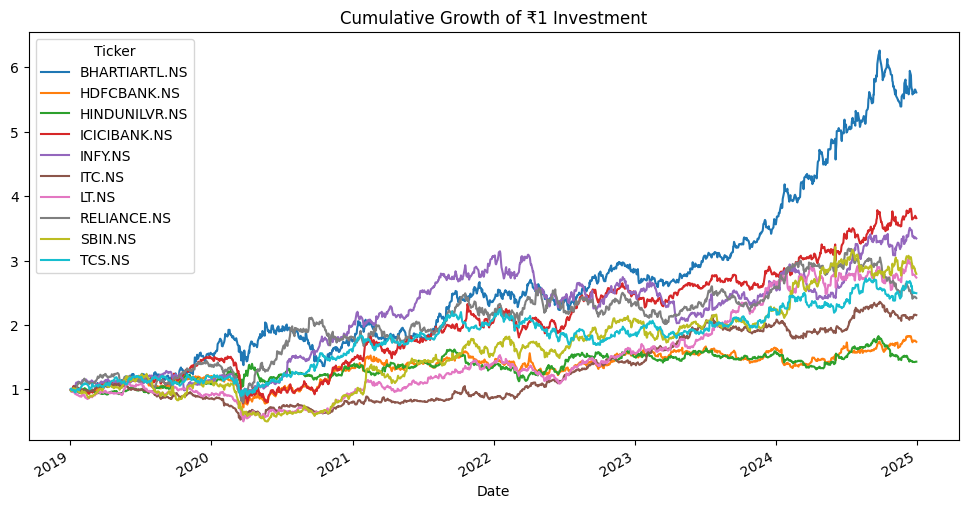

In [319]:
cumulative = (1 + returns).cumprod()

cumulative.plot(figsize=(12,6))
plt.title("Cumulative Growth of ₹1 Investment")
plt.savefig("plot3.jpg", dpi=300, bbox_inches='tight')
plt.show()

✅ Clear Outperformers
Some stocks grew 5–6x, indicating strong long-term appreciation.

✅ Moderate Performers
Most stocks show 2–3x growth over 5 years.

✅ COVID Dip Visible
Sharp fall in early 2020 followed by strong recovery.

✅ Different Recovery Speeds
Some stocks recovered faster → stronger fundamentals.

## Compare With Benchmark

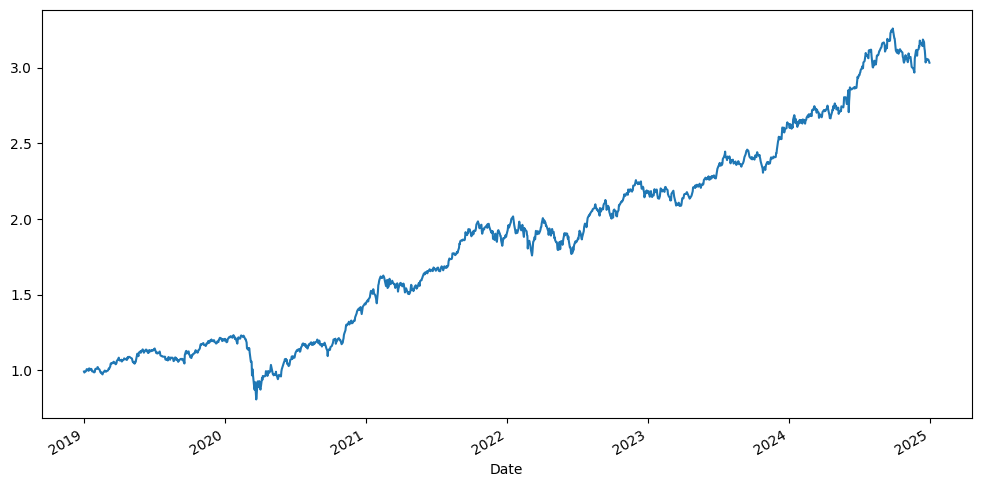

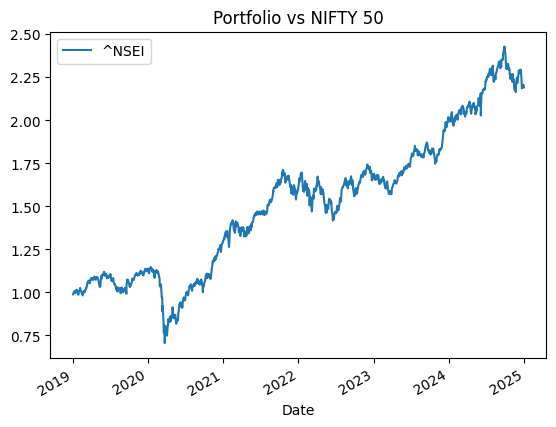

In [322]:
portfolio_avg = returns.mean(axis=1)

plt.figure(figsize=(12,6))
((1+portfolio_avg).cumprod()).plot(label="Equal Weight Portfolio")
((1+nifty_returns).cumprod()).plot(label="NIFTY 50 Index")
plt.legend()
plt.title("Portfolio vs NIFTY 50")
plt.show()

What This Shows:

* Whether active stock selection beats market
* Risk-adjusted comparison possibility

📈 Insights:

✅ Portfolio Shows Strong Uptrend
Consistent compounding over time.

✅ COVID Impact Seen in Both
Market-wide risk exposure confirmed.


# Traditional Optimization Model

* Maximize expected return
* Minimize portfolio variance
* Find optimal asset weights

In [326]:
mean_returns = returns.mean()
cov_matrix = returns.cov()

In [327]:
trading_days = 252
mean_returns = mean_returns * trading_days
cov_matrix = cov_matrix * trading_days

## Define Portfolio Performance Function

In [329]:
def portfolio_performance(weights, mean_returns, cov_matrix):
    returns = np.dot(weights, mean_returns)
    volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return returns, volatility

This function computes expected portfolio return as the weighted average of asset returns and portfolio risk as the square root of the quadratic form involving the covariance matrix. It follows the Markowitz mean-variance optimization framework.

## Minimize Portfolio Volatility

Risk is measured as the standard deviation of portfolio returns, which represents the volatility or variability of returns over time.
* Risk = Standard Deviation of Portfolio Returns

In [333]:
from scipy.optimize import minimize

num_assets = len(mean_returns)

def min_variance(weights):
    return portfolio_performance(weights, mean_returns, cov_matrix)[1]

constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0,1) for _ in range(num_assets))

initial_weights = num_assets * [1./num_assets]

result = minimize(min_variance,
                  initial_weights,
                  method='SLSQP',
                  bounds=bounds,
                  constraints=constraints)

## Get Optimal Weights

In [335]:
optimal_weights = result.x
optimal_return, optimal_volatility = portfolio_performance(
    optimal_weights, mean_returns, cov_matrix
)

print("Optimal Weights:")
print(pd.Series(optimal_weights, index=returns.columns))

print("Expected Annual Return:", round(optimal_return,4))
print("Expected Annual Volatility:", round(optimal_volatility,4))

Optimal Weights:
Ticker
BHARTIARTL.NS    9.982785e-02
HDFCBANK.NS      1.243431e-01
HINDUNILVR.NS    2.588857e-01
ICICIBANK.NS     8.436448e-18
INFY.NS          3.504987e-02
ITC.NS           1.980815e-01
LT.NS            4.649537e-02
RELIANCE.NS      2.994484e-02
SBIN.NS          8.470329e-19
TCS.NS           2.073718e-01
dtype: float64
Expected Annual Return: 0.1672
Expected Annual Volatility: 0.1615


Shows how to invest your money and tells you the expected return and risk of that safest portfolio.

* Return ≈ 16.7%
* Risk ≈ 16.1%

That means risk and return are balanced.

This is what minimum variance portfolio tries to do:
* Reduce risk
* Without destroying returns

## Calculate Sharpe Ratio

In [339]:
risk_free_rate = 0.06   # example 6%

sharpe_ratio = (optimal_return - risk_free_rate) / optimal_volatility

print("Sharpe Ratio:", round(sharpe_ratio,4))

Sharpe Ratio: 0.6637


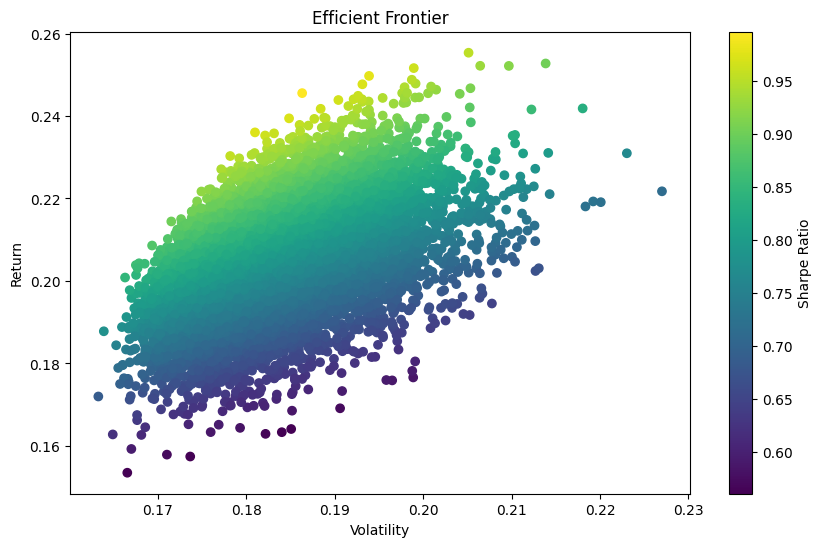

In [340]:
import matplotlib.pyplot as plt

num_portfolios = 10000
results = np.zeros((3, num_portfolios))

for i in range(num_portfolios):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)

    portfolio_return, portfolio_volatility = portfolio_performance(
        weights, mean_returns, cov_matrix
    )

    results[0,i] = portfolio_return
    results[1,i] = portfolio_volatility
    results[2,i] = (portfolio_return - risk_free_rate) / portfolio_volatility

plt.figure(figsize=(10,6))
plt.scatter(results[1,:], results[0,:], c=results[2,:], cmap='viridis')
plt.colorbar(label="Sharpe Ratio")
plt.xlabel("Volatility")
plt.ylabel("Return")
plt.title("Efficient Frontier")
plt.savefig("plot4.jpg", dpi=300, bbox_inches='tight')
plt.show()

Yellow / Light Green:

* High Sharpe Ratio
* Best risk-adjusted return

Blue / Dark:

* Lower Sharpe Ratio
* Less efficient portfolios

The brightest region is usually your Maximum Sharpe Ratio portfolio.

If you invest:

You should choose a portfolio on the top curved boundary

Not one inside the cloud

Because inside points:
*  Same risk but lower return
* Or same return but higher risk

### Where Minimum Variance Portfolio Is

* It will be the left-most point on the curve

* Lowest volatility possible

### Where Maximum Sharpe Portfolio Is

* Usually the brightest yellow point

* Best return per unit of risk

# Behavioral Optimization Model

Behavioral model assumes:
* Losses hurt more than gains feel good

Prospect Theory value function:
* It describes how people actually evaluate potential gains and losses under risk, challenging traditional models of rational decision-making such as expected utility theory.

## Define Prospect Value Function

In [348]:
def prospect_value(x, alpha=0.88, beta=0.88, lam=2.25):
    if x >= 0:
        return x**alpha
    else:
        return -lam * ((-x)**beta)

It converts a return x into how a human emotionally feels about that return.
Not the actual money value. But the psychological value.

* Case 1: When Return is Positive (Gain)
* Case 2: When Return is Negative (Loss)

## Behavioral Utility Function

In [352]:
def behavioral_objective(weights, returns, reference=0):
    portfolio_returns = np.dot(returns, weights)

    utility = np.mean([
        prospect_value(r - reference)
        for r in portfolio_returns
    ])

    return -utility   # negative because we minimize

“Which portfolio makes an investor emotionally happiest, considering that losses hurt more than gains?”

## Optimize Behavioral Portfolio

In [355]:
from scipy.optimize import minimize

num_assets = returns.shape[1]

constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0,1) for _ in range(num_assets))

initial_weights = num_assets * [1./num_assets]

behavioral_result = minimize(
    behavioral_objective,
    initial_weights,
    args=(returns.values, 0),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

* It tries many different weight combinations.
* For each combination:
* It calculates portfolio returns.
* Converts them into psychological values (Prospect Theory).
* Computes average emotional satisfaction.
* It finds the weights that give maximum psychological utility.
* Because you returned -utility, minimizing = maximizing happiness.

## Extract Behavioral Weights

In [358]:
behavioral_weights = behavioral_result.x

print("Behavioral Portfolio Weights:")
print(pd.Series(behavioral_weights, index=returns.columns))

Behavioral Portfolio Weights:
Ticker
BHARTIARTL.NS    0.162462
HDFCBANK.NS      0.073958
HINDUNILVR.NS    0.141053
ICICIBANK.NS     0.048165
INFY.NS          0.107249
ITC.NS           0.132620
LT.NS            0.098963
RELIANCE.NS      0.083091
SBIN.NS          0.015761
TCS.NS           0.136678
dtype: float64


## Compare With Traditional Model

In [360]:
trad_return, trad_vol = portfolio_performance(
    optimal_weights, mean_returns, cov_matrix
)

behav_return, behav_vol = portfolio_performance(
    behavioral_weights, mean_returns, cov_matrix
)

print("Traditional Return:", trad_return)
print("Behavioral Return:", behav_return)

print("Traditional Volatility:", trad_vol)
print("Behavioral Volatility:", behav_vol)

Traditional Return: 0.16720221411017494
Behavioral Return: 0.20353481571906462
Traditional Volatility: 0.16151305074036015
Behavioral Volatility: 0.1686065151151234


## Compare Growth

In [ ]:
trad_port = np.dot(returns, optimal_weights)
behav_port = np.dot(returns, behavioral_weights)

plt.figure(figsize=(10,6))
plt.plot((1 + trad_port).cumprod(), label="Traditional")
plt.plot((1 + behav_port).cumprod(), label="Behavioral")
plt.legend()
plt.savefig("plot5.jpg", dpi=300, bbox_inches='tight')
plt.show()

# What This Graph Shows

* Blue Line → Traditional Portfolio
* Orange Line → Behavioral Portfolio
* X-axis → Time
* Y-axis → Growth of ₹1 invested
* Both start at 1.0 (₹1 invested at beginning).

### What Happened Over Time?
*  Behavioral portfolio stays mostly above traditional

That means:

*  It consistently generated higher cumulative returns.
   At the end:
* Traditional ≈ 2.5
* Behavioral ≈ 3.1

Meaning:

* ₹1 became ₹2.5 in traditional
* ₹1 became ₹3.1 in behavioral

That is a big difference.

### What This Means Logically

### Traditional model:

* Focuses only on volatility (mathematical risk)
### Behavioral model:
* Focuses on avoiding painful losses
* Optimizes psychological utility

And surprisingly…

* It ended up producing higher wealth.

### Important Observation
Look at drawdowns (small crashes):

## Behavioral portfolio:
* Recovers faster
* Falls slightly sharper sometimes
* But overall grows stronger

### That’s why final wealth is higher.